# Preprocessing of CADC trajectories

Crop turning trajectories in CADC dataset

In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/home/zhaohaoa/cadc/cadc_devkit")
sys.path.append("/home/zhaohaoa/cadc/utils")

import pickle
import numpy as np
import matplotlib.pyplot as plt
import cv2
import yaml
import load_novatel_data, convert_novatel_to_pose
from pathlib import Path

from processing_utils import load_data, load_timestamps, convert_to_2d, infer_direction_2d, plot_poses_2d, find_closest_timestamp_inds, extract_pos_vel_acc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
save_path = Path(r"/home/zhaohaoa/navsim/dataset/navsim_logs/cadc")
data_base_path = Path(r"/home/zhaohaoa/cadc/cadcd")

# Loop through all run_paths (only directories) in data_base_path
# Recurse to second level
run_paths = sorted(data_base_path.glob("*/*"))


# run_path = Path(r"/home/zhaohaoa/cadc/cadcd/2018_03_06/0001")
# raw_path = Path(r"/home/zhaohaoa/cadc/cadcd_raw/2018_03_06/0001")


Find all turning trajectories

In [309]:
DIRECTION_MAP = ("left", "forward", "right", "unknown")
inds = []
redownload_runs = []

for ind, run_path in enumerate(run_paths):
    # skip if name is calib
    if "calib" in run_path.name:
        continue
    raw_path = data_base_path.parent / "cadcd_raw" / run_path.relative_to(data_base_path)
    
    try:
        pose_dict = extract_pos_vel_acc(raw_path)
    except Exception as e:
        print(f"Error processing {raw_path}: {e}")
        redownload_runs.append(run_path)
        continue

    poses = pose_dict["poses"]
    direction = infer_direction_2d(poses, yaw_deg=50)

    direction_str = DIRECTION_MAP[np.argmax(direction)]
    if direction_str == "left" or direction_str == "right":
        inds.append(ind)

In [310]:
# to redownload
print("Runs to redownload:")
for r in redownload_runs:
    print(r)

Runs to redownload:


In [312]:
turning_runs = [run_paths[i] for i in inds]
for run in turning_runs:
    print(run)
print(f"Found {len(turning_runs)} turning runs out of {len(run_paths)} total runs.")

/home/zhaohaoa/cadc/cadcd/2018_03_06/0001
/home/zhaohaoa/cadc/cadcd/2018_03_06/0015
/home/zhaohaoa/cadc/cadcd/2018_03_07/0001
/home/zhaohaoa/cadc/cadcd/2018_03_07/0002
/home/zhaohaoa/cadc/cadcd/2018_03_07/0004
/home/zhaohaoa/cadc/cadcd/2018_03_07/0005
/home/zhaohaoa/cadc/cadcd/2018_03_07/0006
/home/zhaohaoa/cadc/cadcd/2018_03_07/0007
/home/zhaohaoa/cadc/cadcd/2019_02_27/0004
/home/zhaohaoa/cadc/cadcd/2019_02_27/0005
/home/zhaohaoa/cadc/cadcd/2019_02_27/0010
/home/zhaohaoa/cadc/cadcd/2019_02_27/0011
/home/zhaohaoa/cadc/cadcd/2019_02_27/0020
/home/zhaohaoa/cadc/cadcd/2019_02_27/0027
/home/zhaohaoa/cadc/cadcd/2019_02_27/0030
/home/zhaohaoa/cadc/cadcd/2019_02_27/0033
/home/zhaohaoa/cadc/cadcd/2019_02_27/0043
/home/zhaohaoa/cadc/cadcd/2019_02_27/0051
/home/zhaohaoa/cadc/cadcd/2019_02_27/0076
/home/zhaohaoa/cadc/cadcd/2019_02_27/0080
/home/zhaohaoa/cadc/cadcd/2019_02_27/0082
Found 21 turning runs out of 78 total runs.


Manually crop the trajectories before and after the turn

In [327]:
all_cut_indices = {
    '2018_03_06/0001': (15, 40),
    '2018_03_06/0012': (-40, -1),
    '2018_03_06/0015': (40, -1),
    '2018_03_07/0001': (0, 20),
    '2018_03_07/0002': (15, 55),
    '2018_03_07/0004': (-40, -1),
    '2018_03_07/0005': (55, 90),
    '2018_03_07/0006': (40, 70),
    '2018_03_07/0007': (50, 75),
    '2019_02_27/0004': (0, 23),
    '2019_02_27/0005': (20, -1),
    '2019_02_27/0010': (5, 40),
    '2019_02_27/0011': (15, -1),
    '2019_02_27/0020': (0, 30),
    '2019_02_27/0027': (20, 45),
    '2019_02_27/0030': (0, 15),
    '2019_02_27/0033': (65, 95),
    '2019_02_27/0043': (25, 55),
    '2019_02_27/0046': (0, -1),
    '2019_02_27/0051': (60, 90),
    '2019_02_27/0076': (15, 40),
    '2019_02_27/0080': (10, -1),
    '2019_02_27/0082': (5, 35),
}

In [328]:
# remaining = turning_runs
remaining = sorted(list(set(turning_runs) - {data_base_path / p for p in all_cut_indices.keys()}))

if remaining:
    print(f"Remaining runs to process: {len(remaining)}")

    i = 0
    cut_indices = (0, -1)
    cut_indices = (5, 35)

    # run_path = turning_runs[i]
    run_path = remaining[i]
    raw_path = data_base_path.parent / "cadcd_raw" / run_path.relative_to(data_base_path)

    # Path relative to data_base_path
    log_name = run_path.relative_to(data_base_path)


    pose_dict = extract_pos_vel_acc(raw_path)
    poses = pose_dict["poses"]

    direction = infer_direction_2d(poses, yaw_deg=50)

    # Plot poses
    fig, ax = plt.subplots(figsize=(5, 5))
    plot_poses_2d(poses[cut_indices[0]:cut_indices[1]], ax=ax)
    ax.set_title(f"Direction: {DIRECTION_MAP[np.argmax(direction)]}")
    plt.show()

    print(f"'{log_name}': {cut_indices},")

else:
    print("No remaining runs to process.")

No remaining runs to process.


Save/load all_cut_in_trajectories to/from a file

In [326]:
def save_cut_indices(cut_indices_dict, save_path):
    with open(save_path / "cut_indices.pkl", "wb") as f:
        pickle.dump(cut_indices_dict, f)
    print(f"Saved cut indices to {save_path / 'cut_indices.pkl'}")

def load_cut_indices(load_path):
    print(f"Loading cut indices from {load_path}")
    with open(load_path, "rb") as f:
        return pickle.load(f)

    
SAVE_PATH = Path("/home/zhaohaoa/cadc")
save_cut_indices(all_cut_indices, SAVE_PATH)
all_cut_indices = load_cut_indices(SAVE_PATH / "cut_indices.pkl")


Saved cut indices to /home/zhaohaoa/cadc/cut_indices.pkl
Loading cut indices from /home/zhaohaoa/cadc/cut_indices.pkl


In [318]:
# Delete entries that are not in turning_runs
# all_cut_indices = {k: v for k, v in all_cut_indices.items() if data_base_path / k in turning_runs}
# assert len(all_cut_indices) == len(turning_runs), "Cut indices should be provided for all turning runs."

## Visualization of cropped trajectories

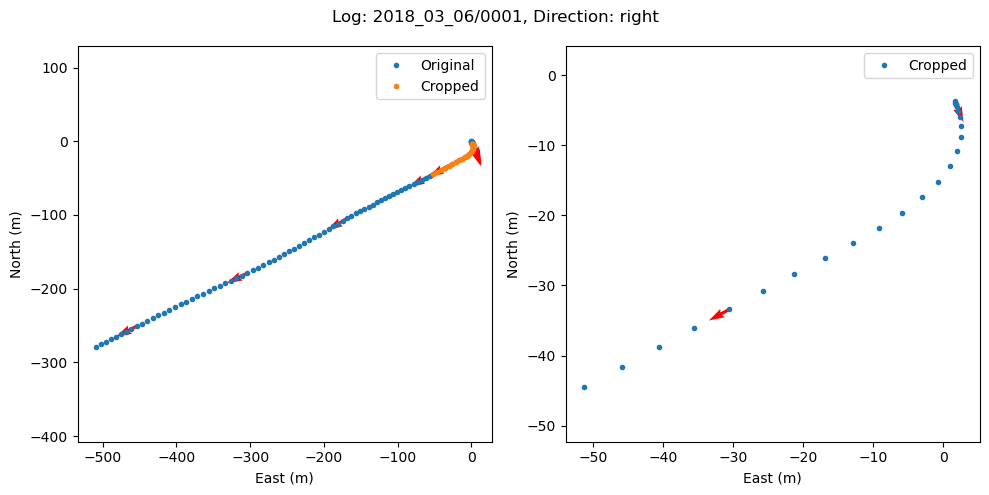

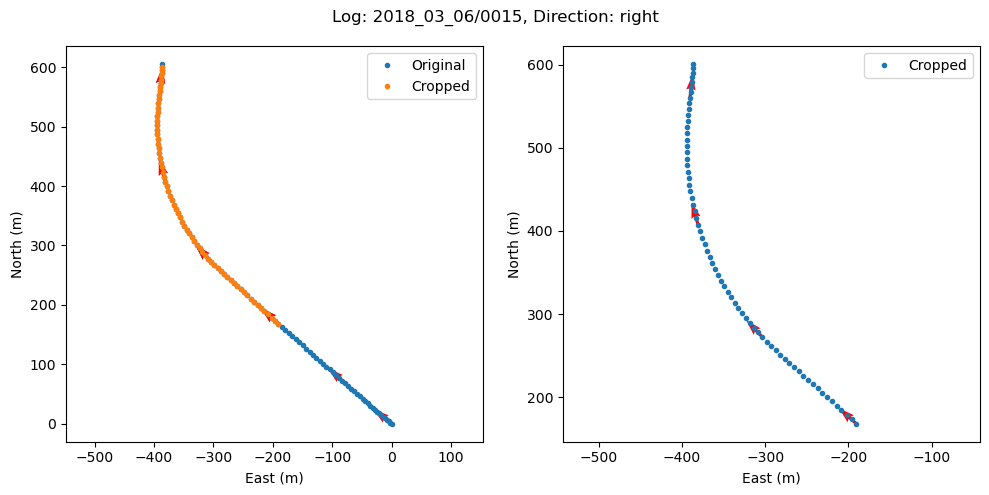

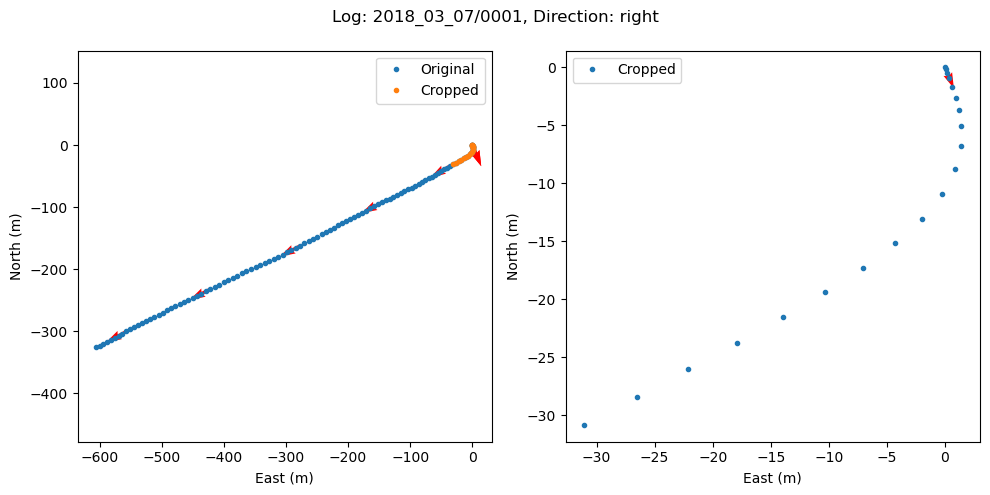

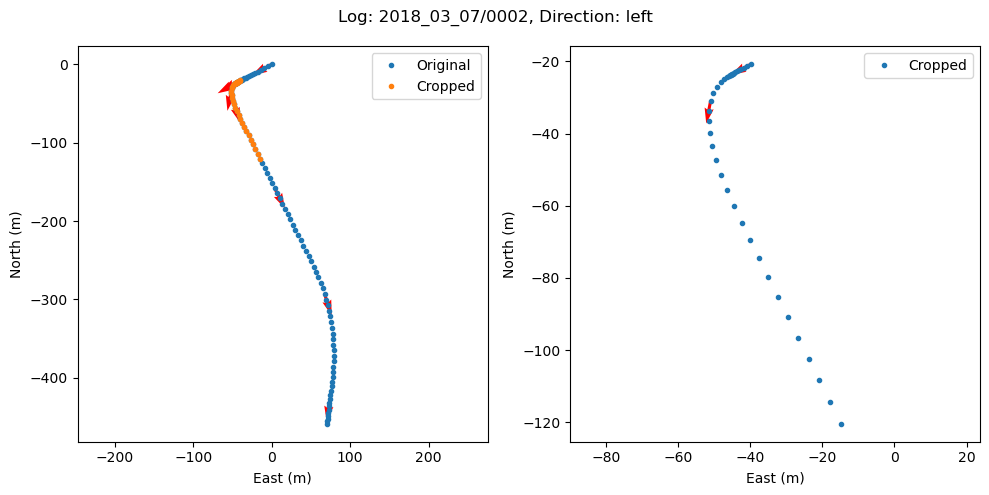

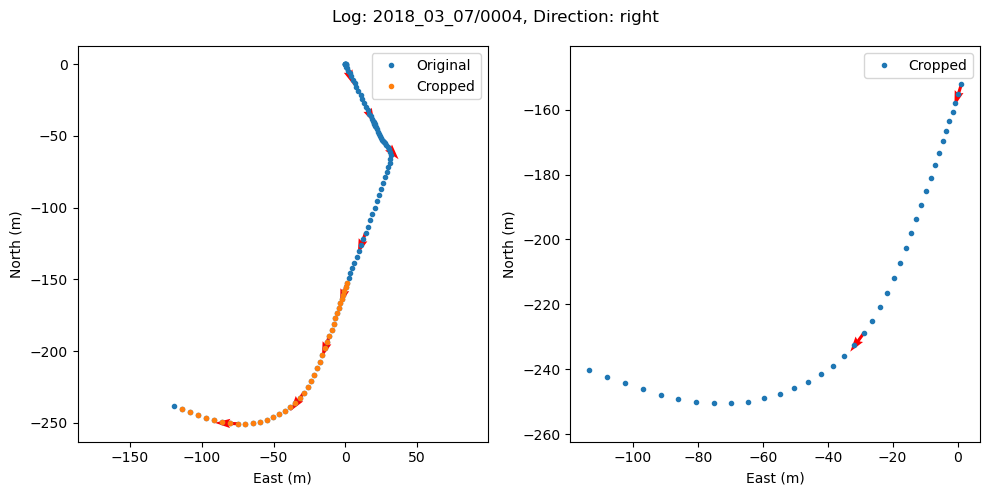

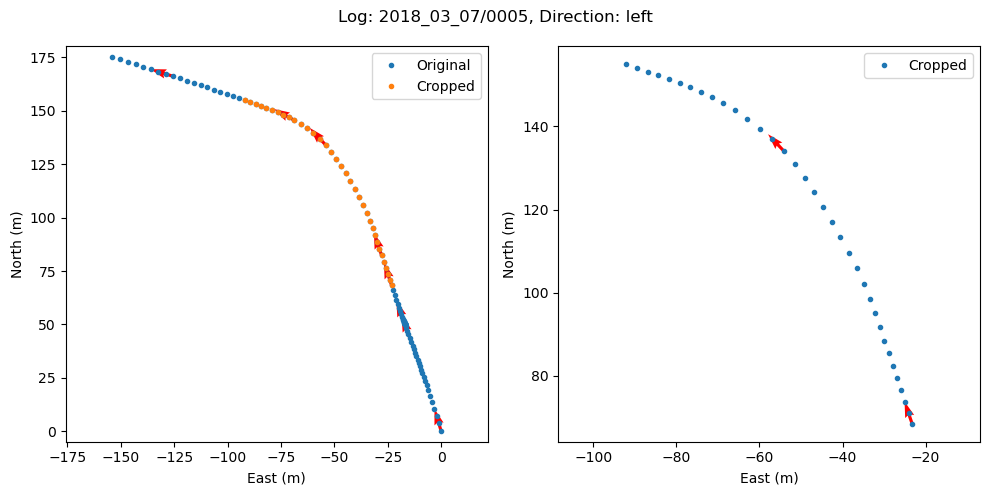

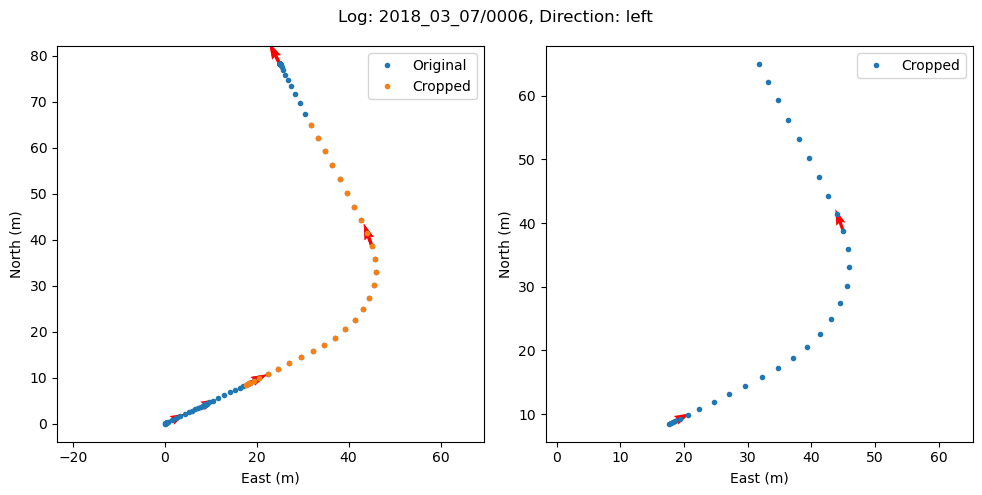

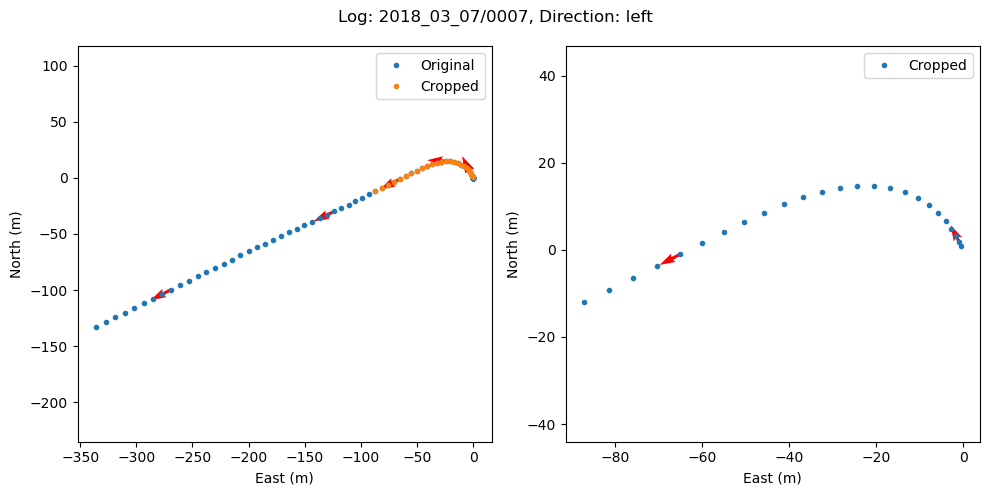

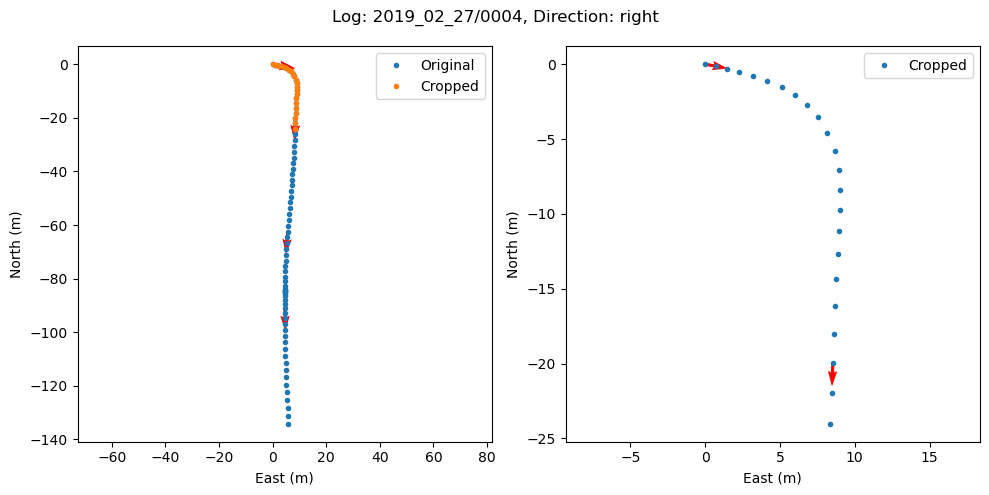

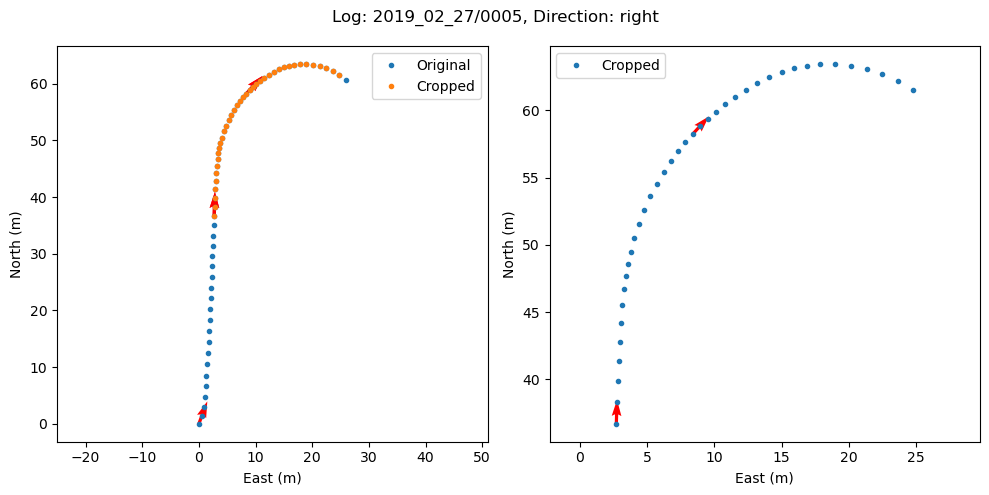

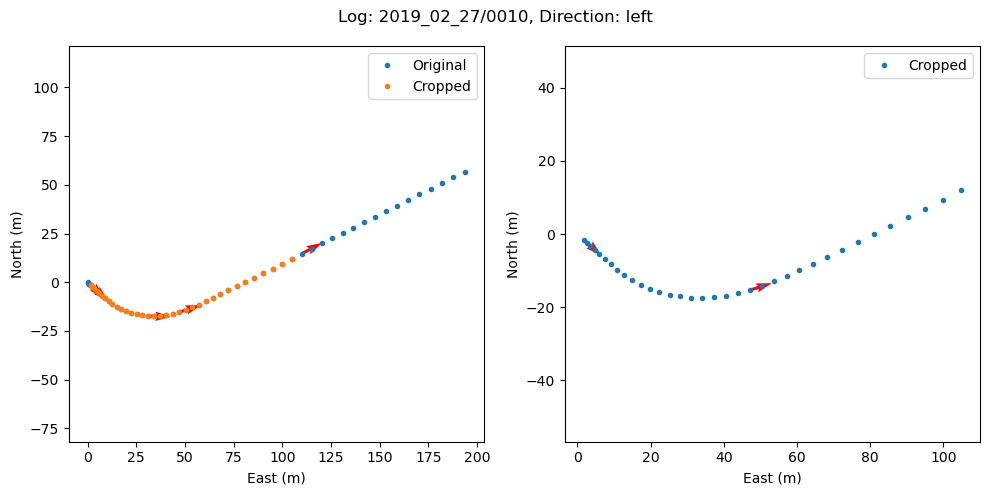

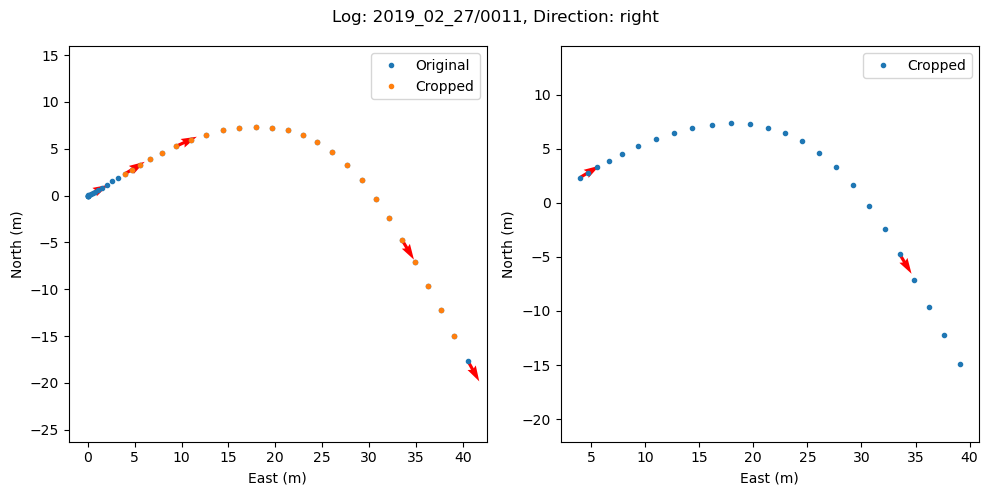

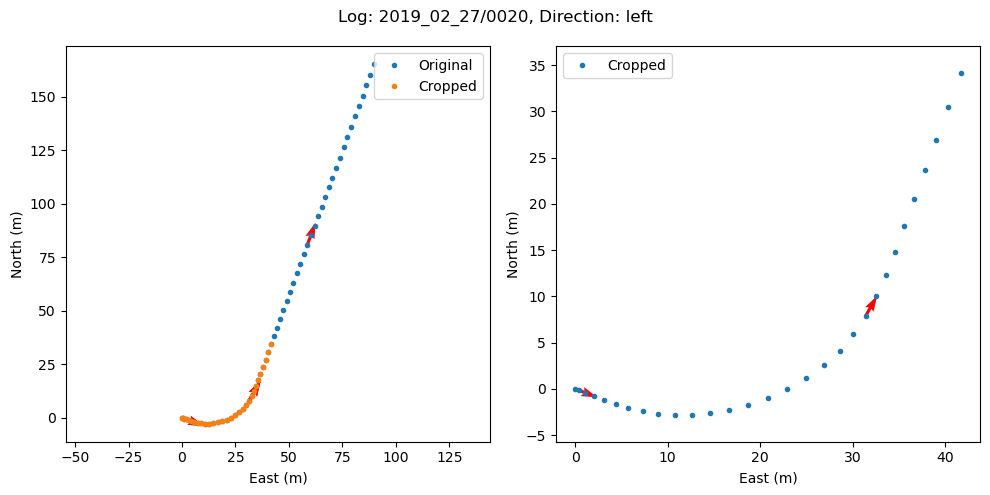

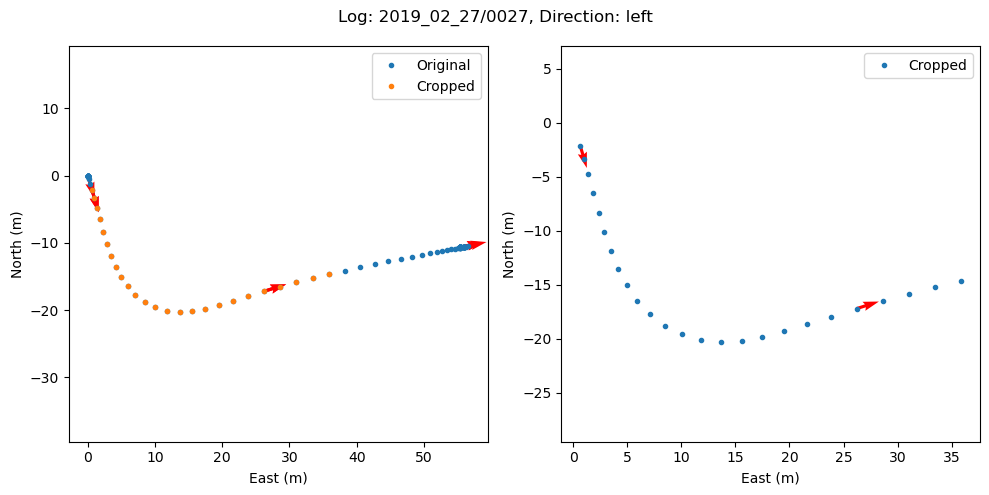

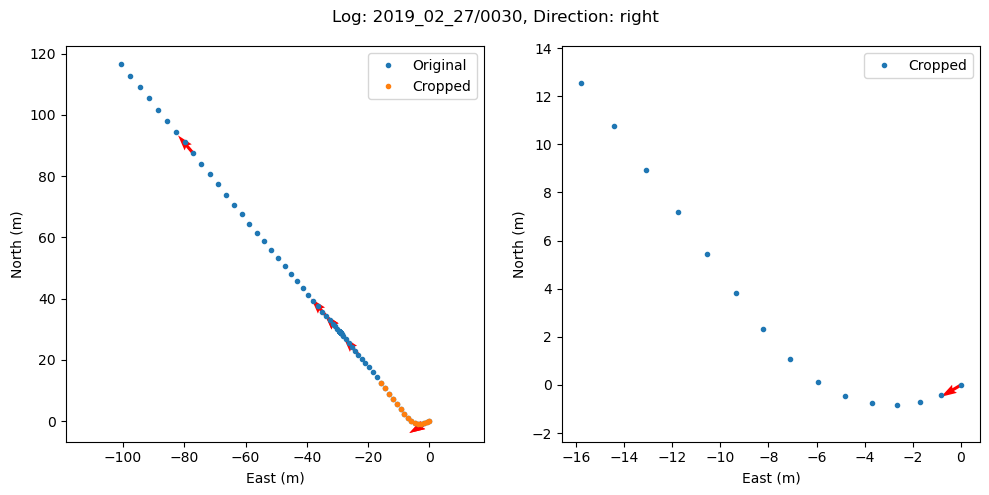

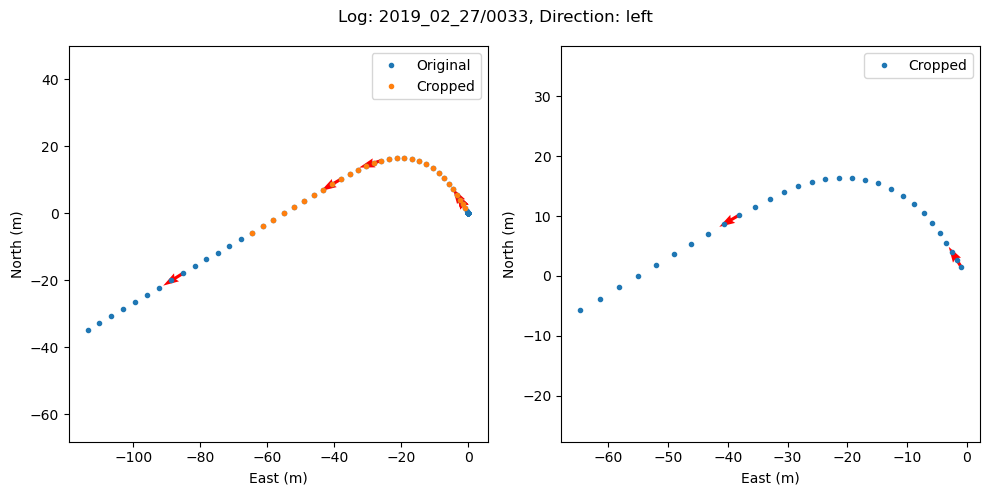

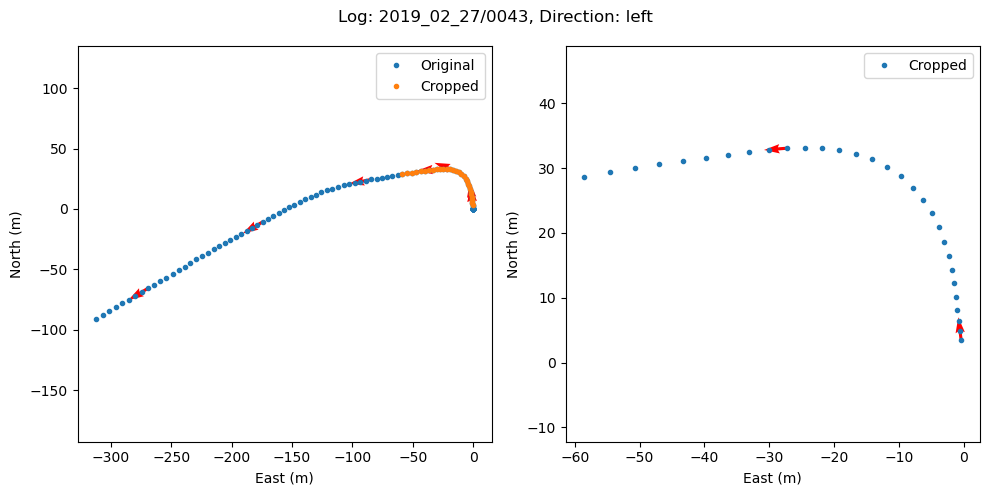

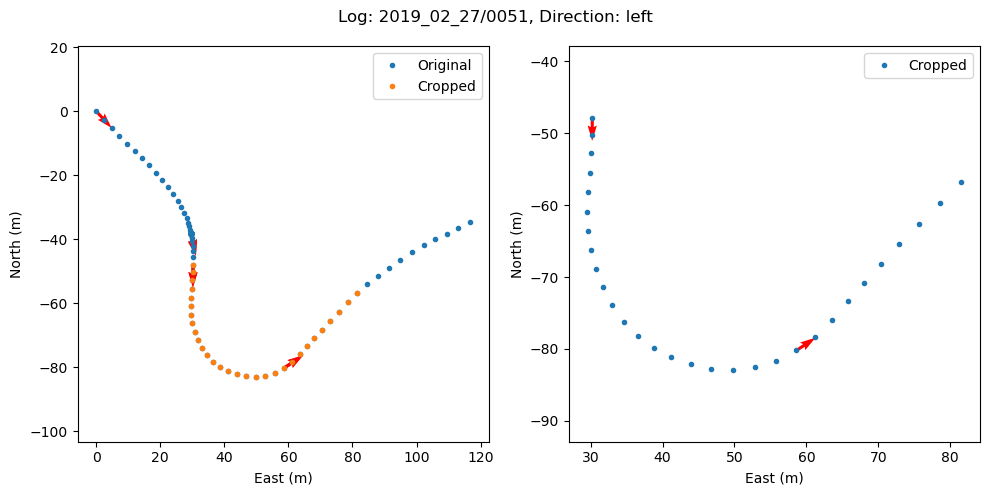

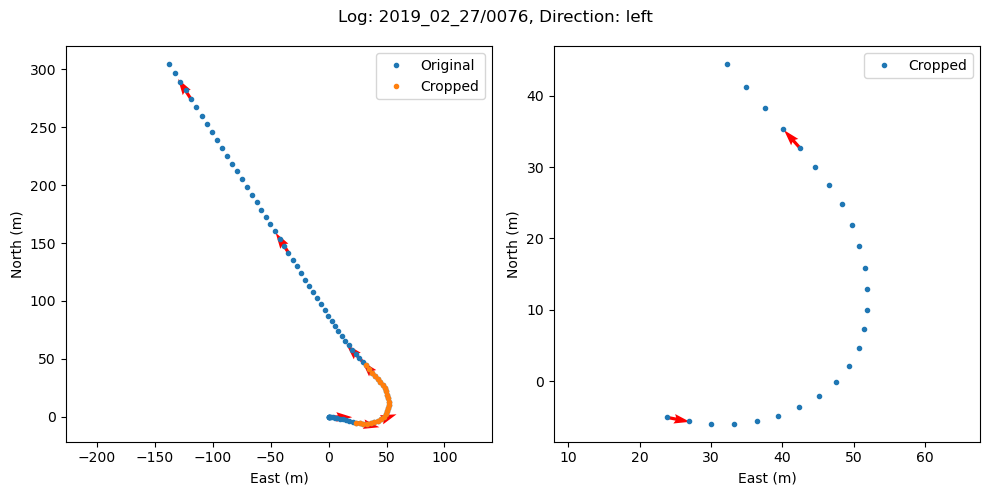

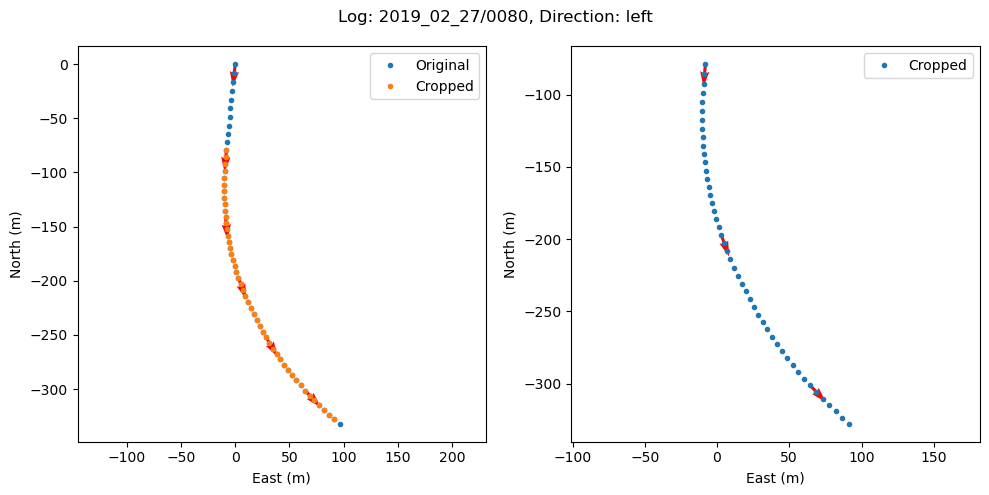

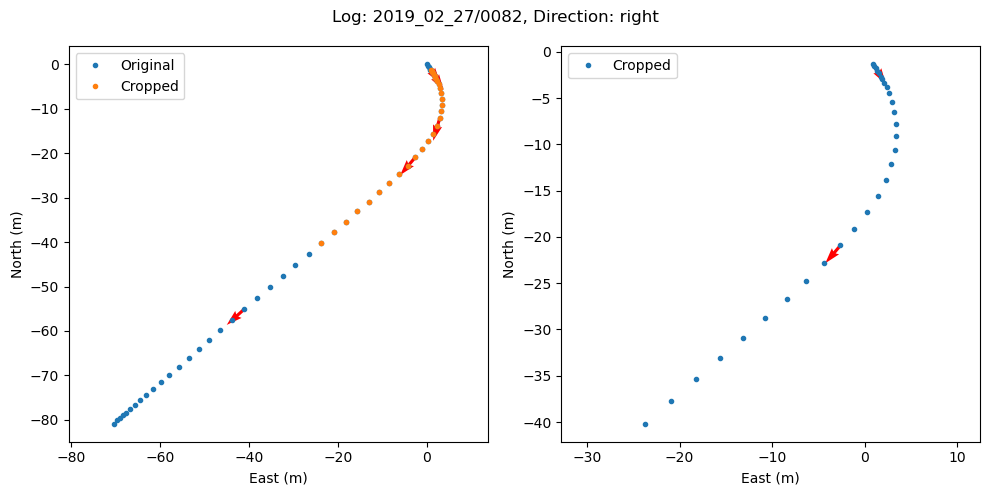

In [317]:
# Plot original trajectory next to cropped trajectory for comparison

for log_name, cut_indices in all_cut_indices.items():
    run_path = data_base_path / log_name
    raw_path = data_base_path.parent / "cadcd_raw" / log_name

    pose_dict = extract_pos_vel_acc(raw_path)
    poses = pose_dict["poses"]

    direction = infer_direction_2d(poses, yaw_deg=50)

    # Plot poses
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    plot_poses_2d(poses, ax=axs[0], label="Original")
    plot_poses_2d(poses[cut_indices[0]:cut_indices[1]], ax=axs[0], label="Cropped")
    # Plot cropped trajectory
    plot_poses_2d(poses[cut_indices[0]:cut_indices[1]], ax=axs[1], label="Cropped")
    for ax in axs:
        ax.set_aspect("equal")
        ax.legend()

    plt.suptitle(f"Log: {log_name}, Direction: {DIRECTION_MAP[np.argmax(direction)]}")
    plt.tight_layout()
    plt.show()
